# 😷 Face Mask Detection using YOLOv8

## 📌 Project Overview
This project focuses on detecting whether individuals are wearing masks or not using the **YOLOv8** object detection model. The model is trained on a custom dataset downloaded via **Roboflow** to perform real-time and accurate bounding-box predictions.

---

## 🎯 Objectives
* Download and prepare the **Mask-Wearing Dataset** using Roboflow.
* Explore and analyze dataset annotations and visual samples.
* Train a **YOLOv8 (Nano)** model on custom classes (`mask` / `no mask`).
* Evaluate model metrics including **Precision**, **Recall**, and **mAP**.
* Perform inference on unseen test images to verify performance.

---


## 📊 Dataset Classes
* **0:** `mask` (Green Bounding Box)
* **1:** `no mask` (Red Bounding Box)

# 📂 Loading the Dataset

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="F0r1jh1YihYZ6hHwGrmX")
project = rf.workspace("joseph-nelson").project("mask-wearing")
version = project.version(19)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 4.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 67.6 MB/s eta 0:00:00:00:0100:01
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mask-Wearing-19 in yolov8:: 100%|██████████| 3880/3880 [00:00<00:00, 6185.80it/s]


# 📦 Import Libraries

In [3]:
# Install Ultralytics library (includes YOLOv8 models and utilities)
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.6 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import yaml
import pandas as pd
import numpy as np
import os
import random

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


# Exploratory Data Analysis (EDA)

In [5]:
dataset_path = "/kaggle/working/Mask-Wearing-19"

In [6]:
splits = ["train", "valid", "test"]

dfs = {}

for split in splits:

    image_dir = os.path.join(dataset_path, split, "images")
    label_dir = os.path.join(dataset_path, split, "labels")

    data = []

    for img in os.listdir(image_dir):

        image_name = os.path.splitext(img)[0]

        label_name = image_name + ".txt"

        image_path = os.path.join(image_dir, img)
        label_path = os.path.join(label_dir, label_name)

        if os.path.exists(label_path):
            data.append({
                "image": image_path,
                "label": label_path
            })

    df = pd.DataFrame(data)

    dfs[split] = df

    print(f"\n========== {split.upper()} ==========")
    print("Number of images:", len(os.listdir(image_dir)))
    print("Number of labels:", len(os.listdir(label_dir)))
    print("Number of matched pairs:", len(df))


========== TRAIN ==========
Number of images: 1366
Number of labels: 1366
Number of matched pairs: 1366

========== VALID ==========
Number of images: 368
Number of labels: 368
Number of matched pairs: 368

========== TEST ==========
Number of images: 200
Number of labels: 200
Number of matched pairs: 200


In [7]:
with open(df["label"][0], "r") as f:
    labels = f.readlines()

print("Annotation File Content:\n")

for line in labels:
    print(line.strip())

Annotation File Content:

0 0.49806249999999996 0.32330555555555557 0.15867187499999993 0.2824027777777778


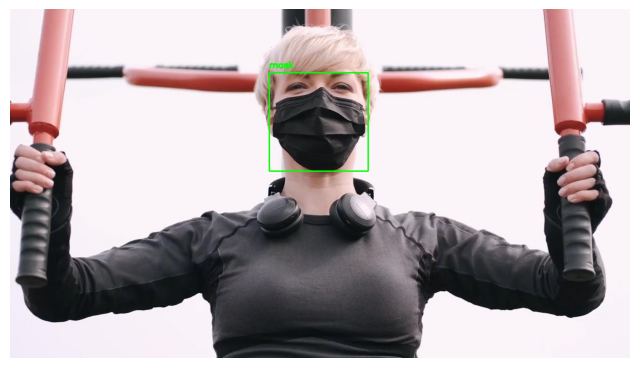

In [8]:
image = plt.imread(df["image"][0]).copy()

img_h, img_w = image.shape[:2]


class_names = ["mask", "no mask"]


with open(df["label"][0], "r") as f:

    for line in f.readlines():

        class_id, x_center, y_center, width, height = map(float, line.split())

        x_center *= img_w
        y_center *= img_h
        width *= img_w
        height *= img_h

        x_min = int(x_center - width / 2)
        y_min = int(y_center - height / 2)
        x_max = int(x_center + width / 2)
        y_max = int(y_center + height / 2)

        color = (0, 255, 0) if int(class_id) == 0 else (255, 0, 0)

        cv2.rectangle(
            image,
            (x_min, y_min),
            (x_max, y_max),
            color,
            2
        )

        cv2.putText(
            image,
            class_names[int(class_id)],
            (x_min, y_min - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

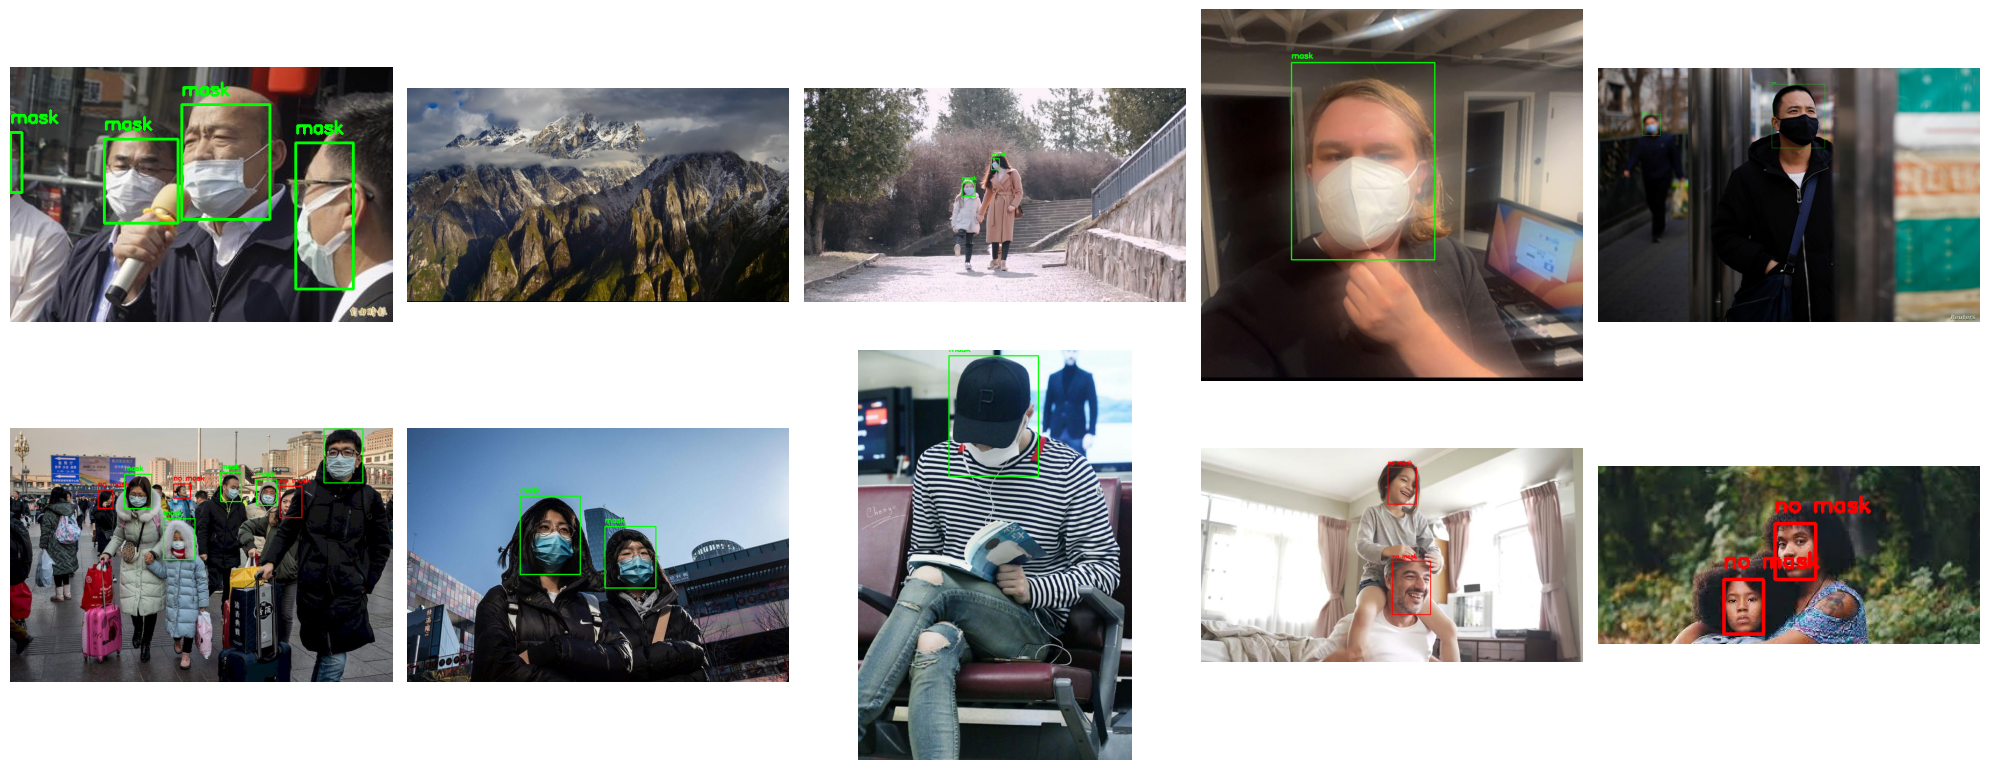

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax in axes:

    idx = random.randint(0, len(df)-1)

    image_path = df["image"][idx]
    label_path = df["label"][idx]

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_h, img_w = image.shape[:2]

    with open(label_path, "r") as f:

        for line in f.readlines():

            class_id, x_center, y_center, width, height = map(float, line.split())

            x_center *= img_w
            y_center *= img_h
            width *= img_w
            height *= img_h

            x_min = int(x_center - width / 2)
            y_min = int(y_center - height / 2)

            x_max = int(x_center + width / 2)
            y_max = int(y_center + height / 2)

            color = (0, 255, 0) if int(class_id) == 0 else (255, 0, 0)

            cv2.rectangle(
                image,
                (x_min, y_min),
                (x_max, y_max),
                color,
                2
            )

            cv2.putText(
                image,
                class_names[int(class_id)],
                (x_min, y_min - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from collections import Counter

class_counter = Counter()

total_objects = 0

label_dir = os.path.join(dataset_path, "train", "labels")

for label_file in os.listdir(label_dir):

    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:

        for line in f.readlines():

            class_id = int(line.split()[0])

            class_counter[class_id] += 1
            total_objects += 1

print(f"Total Objects: {total_objects}\n")

for class_id, count in class_counter.items():

    print(
        f"{class_names[class_id]} : {count}"
    )

Total Objects: 2576

mask : 1568
no mask : 1008


In [11]:
import yaml
import os # Import the os module

yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

data_config

{'names': ['mask', 'no-mask'],
 'nc': 2,
 'roboflow': {'license': 'Public Domain',
  'project': 'mask-wearing',
  'url': 'https://universe.roboflow.com/joseph-nelson/mask-wearing/dataset/19',
  'version': 19,
  'workspace': 'joseph-nelson'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

# 📥 Download & Initialize YOLOv8 Model

In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.info()


YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8550912)

In [13]:
metrics = model.val(data=yaml_path, split="test")  

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1484.9±187.0 MB/s, size: 62.2 KB)
val: Scanning /kaggle/working/Mask-Wearing-19/test/labels... 200 images, 35 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 1.4Kit/s 0.1s<0.1s
val: New cache created: /kaggle/working/Mask-Wearing-19/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.3it/s 3.9s0.1s
                   all        200        377     0.0302     0.0486    0.00944    0.00281
                person         98        288     0.0604     0.0972     0.0189    0.00561
               bicycle         77         89          0          0          0          0
Speed: 1.2ms preprocess, 5.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


In [14]:
print("Precision (mP):", metrics.box.mp)
print("Recall (mR):", metrics.box.mr)
print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)

Precision (mP): 0.030175595372621582
Recall (mR): 0.04861111111111111
mAP@50: 0.009436014632446534
mAP@50-95: 0.002807177821224768


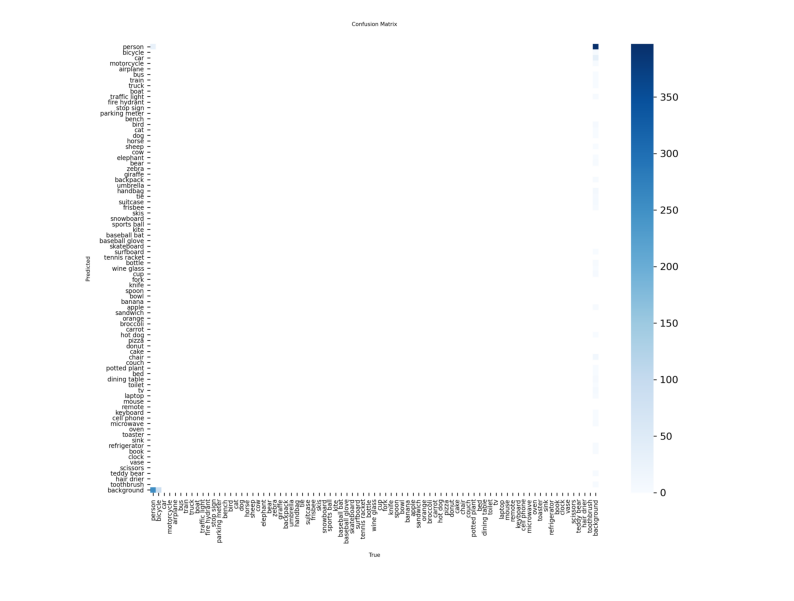

In [15]:
import matplotlib.pyplot as plt
import cv2

# عرض Confusion Matrix
cm_path = "runs/detect/val/confusion_matrix.png"
if os.path.exists(cm_path):
    img = cv2.imread(cm_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# 🚀 2. Model Training (Fine-Tuning)

In [16]:
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name="mask-detection_yolov8",
    freeze=None,
    pretrained=True,
    patience=7,

)

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Mask-Wearing-19/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask-detection_yolov8, nbs=64, nms=

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


       2/50       2.4G      1.395       1.85      1.358         17        640: 100% ━━━━━━━━━━━━ 86/86 6.6it/s 13.0s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 5.0it/s 2.4s0.2s
                   all        368        709      0.726      0.538      0.619      0.325

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50       2.4G      1.388      1.597      1.358         28        640: 100% ━━━━━━━━━━━━ 86/86 6.6it/s 13.1s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 5.4it/s 2.2s0.2s
                   all        368        709      0.662      0.588      0.643      0.339

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50       2.4G      1.392      1.461      1.362         35        640: 100% ━━━━━━━━━━━━ 86/86 6.7it/s 12.9s0.3s
                 Class     Images  Inst

# 📈 Model Evaluation

In [17]:
print("Precision:", results.box.mp)
print("Recall:", results.box.mr)
print("mAP@50:", results.box.map50)
print("mAP@50-95:", results.box.map)

Precision: 0.9606504178435473
Recall: 0.8343261381705658
mAP@50: 0.9438046309389347
mAP@50-95: 0.6779172782616099


In [18]:
best_model = YOLO("/kaggle/working/runs/detect/mask-detection_yolov8/weights/best.pt")

test_metrics = best_model.val(data=yaml_path, split="test")

print("=== TEST METRICS ===")
print("Precision (mP):", test_metrics.box.mp)
print("Recall (mR):", test_metrics.box.mr)
print("mAP@50:", test_metrics.box.map50)
print("mAP@50-95:", test_metrics.box.map)

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1377.9±918.4 MB/s, size: 56.6 KB)
val: Scanning /kaggle/working/Mask-Wearing-19/test/labels.cache... 200 images, 35 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 83.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 5.5it/s 2.4s0.1s
                   all        200        377      0.918      0.857      0.894      0.626
                  mask         98        288      0.886      0.826      0.862      0.514
               no-mask         77         89       0.95      0.888      0.927      0.738
Speed: 1.5ms preprocess, 3.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
=== TEST METRICS ===
Precision (mP): 0.9177180824312883
Recall (mR): 0.857

In [19]:

test_images_dir = os.path.join(dataset_path, "test", "images")

test_images = random.sample(
    os.listdir(test_images_dir),
    5
)

image_paths = [
    os.path.join(test_images_dir, img)
    for img in test_images
]

results = model.predict(
    source=image_paths,
    conf=0.25,
    save=True
)


0: 640x640 1 no-mask, 5.1ms
1: 640x640 (no detections), 5.1ms
2: 640x640 4 masks, 5.1ms
3: 640x640 1 no-mask, 5.1ms
4: 640x640 1 no-mask, 5.1ms
Speed: 1.9ms preprocess, 5.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


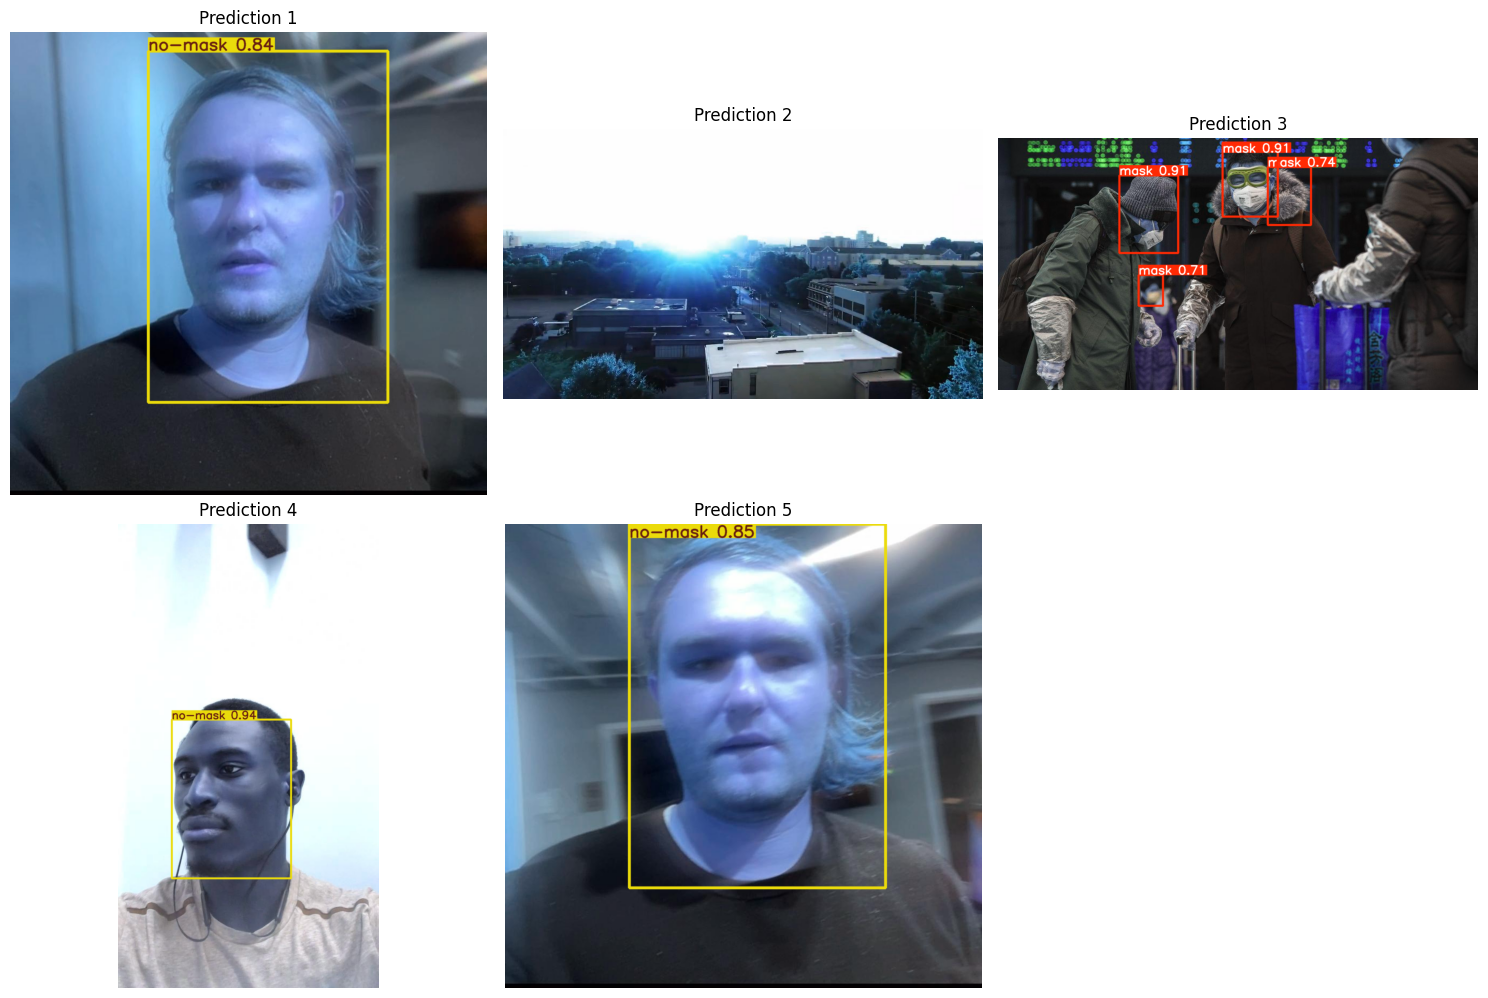

In [20]:
plt.figure(figsize=(15, 10))

for i, result in enumerate(results):

    image = result.plot()

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Prediction {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


0: 640x640 1 no-mask, 5.1ms
1: 640x640 (no detections), 5.1ms
2: 640x640 4 masks, 5.1ms
3: 640x640 1 no-mask, 5.1ms
4: 640x640 1 no-mask, 5.1ms
Speed: 1.7ms preprocess, 5.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


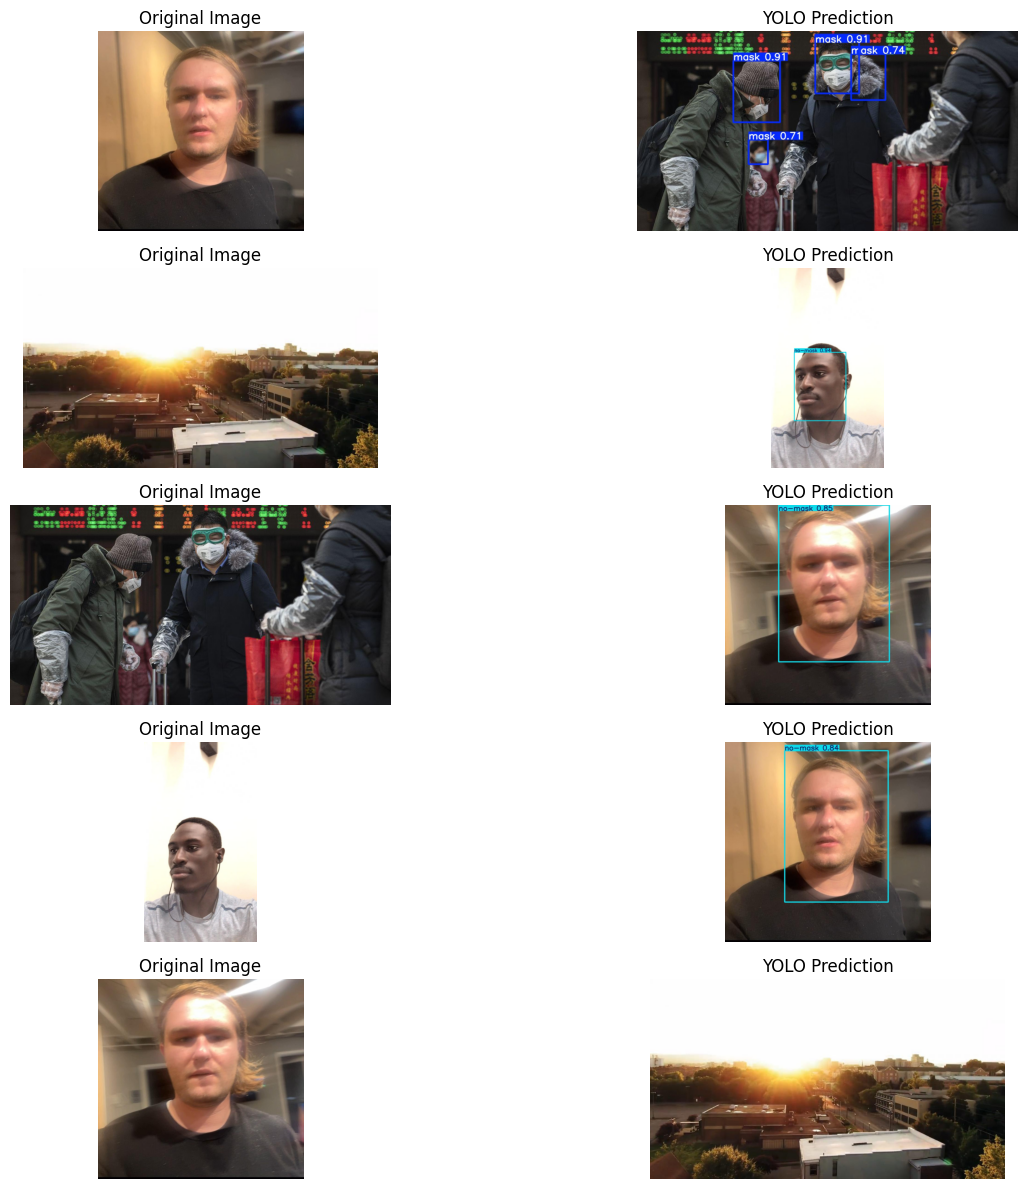

In [21]:
import matplotlib.pyplot as plt
import cv2
import os

# Run inference first
results = model.predict(
    source=image_paths,
    conf=0.25,
    save=True
)

prediction_dir = "runs/detect/predict"

predicted_images = sorted(os.listdir(prediction_dir))

plt.figure(figsize=(16, 12))

for i in range(len(image_paths)):


    original_image = cv2.imread(image_paths[i])
    original_image = cv2.cvtColor(
        original_image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(len(image_paths), 2, 2*i + 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")


    predicted_path = os.path.join(
        prediction_dir,
        predicted_images[i]
    )

    predicted_image = cv2.imread(predicted_path)
    predicted_image = cv2.cvtColor(
        predicted_image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(len(image_paths), 2, 2*i + 2)
    plt.imshow(predicted_image)
    plt.title("YOLO Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()





# Saving Model

In [22]:
from IPython.display import FileLink


FileLink(r'runs/detect/mask-detection_yolov8/weights/best.pt')

/kaggle/working/runs/detect/mask-detection_yolov8/weights/best.pt

In [23]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/runs/detect/mask-detection_yolov8/weights/best.pt')

model.export(format='onnx')

FileLink(r'runs/detect/mask-detection_yolov8/weights/best.onnx')

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/mask-detection_yolov8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 361ms
Prepared 2 packages in 413ms
Installed 2 packages in 9ms
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 1.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export succe

/kaggle/working/runs/detect/mask-detection_yolov8/weights/best.onnx